In [514]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [515]:
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [516]:
from mtu_plots import graph_metrics_models_and_mtu
print(matplotlib.__version__)

3.6.3


In [517]:
DEBUG = True

In [518]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})
plotting_sigma = 0.1
mult_sd = 0.25

colors = {
    'content_reduced' : 'tab:green',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'tab:purple',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink'
}

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_reduced": "Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

rand_results_to_readable = {
    "testing_feeds\\rs_100" : "RS: 100%\nRand: 0%",
    "testing_feeds\\rs_rand_25\\r3" : "RS: 75%\nRand: 25%",
    "testing_feeds\\rs_rand_25\\r2" : "RS: 50%\nRand: 50%",
    "testing_feeds\\rs_rand_25\\r1" : "RS: 25%\nRand: 75%",
    "testing_feeds\\rs_rand_25\\r0" : "RS: 0%\nRand: 100%",
}

rand_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nRand: 0%",
    "testing_feeds\\rs_rand_25_no_rep\\r3" : "RS: 75%\nRand: 25%",
    "testing_feeds\\rs_rand_25_no_rep\\r2" : "RS: 50%\nRand: 50%",
    "testing_feeds\\rs_rand_25_no_rep\\r1" : "RS: 25%\nRand: 75%",
    "testing_feeds\\rs_rand_25_no_rep\\r0" : "RS: 0%\nRand: 100%",
}

ideal_results_to_readable = {
    "testing_feeds\\rs_100" : "RS: 100%\nIdeal: 0%",
    "testing_feeds\\rs_ideal_25\\r3" : "RS: 75%\nIdeal: 25%",
    "testing_feeds\\rs_ideal_25\\r2" : "RS: 50%\nIdeal: 50%",
    "testing_feeds\\rs_ideal_25\\r1" : "RS: 25%\nIdeal: 75%",
    "testing_feeds\\rs_ideal_25\\r0" : "RS: 0%\nIdeal: 100%",
}

ideal_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nIdeal: 0%",
    "testing_feeds\\rs_ideal_25_no_rep\\r3" : "RS: 75%\nIdeal: 25%",
    "testing_feeds\\rs_ideal_25_no_rep\\r2" : "RS: 50%\nIdeal: 50%",
    "testing_feeds\\rs_ideal_25_no_rep\\r1" : "RS: 25%\nIdeal: 75%",
    "testing_feeds\\rs_ideal_25_no_rep\\r0" : "RS: 0%\nIdeal: 100%",
}

trend_results_to_readable = {
    "testing_feeds\\rs_100" : "RS: 100%\nTrend: 0%",
    "testing_feeds\\rs_trend_25\\r3" : "RS: 75%\nTrend: 25%",
    "testing_feeds\\rs_trend_25\\r2" : "RS: 50%\nTrend: 50%",
    "testing_feeds\\rs_trend_25\\r1" : "RS: 25%\nTrend: 75%",
    "testing_feeds\\rs_trend_25\\r0" : "RS: 0%\nTrend: 100%",
}

trend_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nTrend: 0%",
    "testing_feeds\\rs_trend_25_no_rep\\r3" : "RS: 75%\nTrend: 25%",
    "testing_feeds\\rs_trend_25_no_rep\\r2" : "RS: 50%\nTrend: 50%",
    "testing_feeds\\rs_trend_25_no_rep\\r1" : "RS: 25%\nTrend: 75%",
    "testing_feeds\\rs_trend_25_no_rep\\r0" : "RS: 0%\nTrend: 100%",
}

pop_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nPop: 0%",
    "testing_feeds\\rs_pop_25_no_rep\\r3" : "RS: 75%\nPop: 25%",
    "testing_feeds\\rs_pop_25_no_rep\\r2" : "RS: 50%\nPop: 50%",
    "testing_feeds\\rs_pop_25_no_rep\\r1" : "RS: 25%\nPop: 75%",
    "testing_feeds\\rs_pop_25_no_rep\\r0" : "RS: 0%\nPop: 100%",
}

new_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nNew: 0%",
    "testing_feeds\\rs_new_25_no_rep\\r3" : "RS: 75%\nNew: 25%",
    "testing_feeds\\rs_new_25_no_rep\\r2" : "RS: 50%\nNew: 50%",
    "testing_feeds\\rs_new_25_no_rep\\r1" : "RS: 25%\nNew: 75%",
    "testing_feeds\\rs_new_25_no_rep\\r0" : "RS: 0%\nNew: 100%",
}

social_no_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nSocial: 0%",
    "testing_feeds\\rs_social_25_no_rep\\r3" : "RS: 75%\nSocial: 25%",
    "testing_feeds\\rs_social_25_no_rep\\r2" : "RS: 50%\nSocial: 50%",
    "testing_feeds\\rs_social_25_no_rep\\r1" : "RS: 25%\nSocial: 75%",
    "testing_feeds\\rs_social_25_no_rep\\r0" : "RS: 1%\nSocial: 99%",
}

pop_no_feed_rep_results_to_readable = {
    "testing_feeds\\rs_100_no_rep" : "RS: 100%\nPop: 0%",
    "testing_feeds\\rs_pop_25_no_feed_rep\\r3" : "RS: 75%\nPop: 25%",
    "testing_feeds\\rs_pop_25_no_feed_rep\\r2" : "RS: 50%\nPop: 50%",
    "testing_feeds\\rs_pop_25_no_feed_rep\\r1" : "RS: 25%\nPop: 75%",
    "testing_feeds\\rs_pop_25_no_feed_rep\\r0" : "RS: 0%\nPop: 100%",
}

results_to_readable = pop_no_feed_rep_results_to_readable

In [519]:
rand_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nRand: 0%",
    "testing_feeds\\new_CBF\\rs_rand_25_no_rep\\r3" : "RS: 75%\nRand: 25%",
    "testing_feeds\\new_CBF\\rs_rand_25_no_rep\\r2" : "RS: 50%\nRand: 50%",
    "testing_feeds\\new_CBF\\rs_rand_25_no_rep\\r1" : "RS: 25%\nRand: 75%",
    "testing_feeds\\new_CBF\\rs_rand_25_no_rep\\r0" : "RS: 0%\nRand: 100%",
}

ideal_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nIdeal: 0%",
    "testing_feeds\\new_CBF\\rs_ideal_25_no_rep\\r3" : "RS: 75%\nIdeal: 25%",
    "testing_feeds\\new_CBF\\rs_ideal_25_no_rep\\r2" : "RS: 50%\nIdeal: 50%",
    "testing_feeds\\new_CBF\\rs_ideal_25_no_rep\\r1" : "RS: 25%\nIdeal: 75%",
    "testing_feeds\\new_CBF\\rs_ideal_25_no_rep\\r0" : "RS: 0%\nIdeal: 100%",
}

trend_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nTrend: 0%",
    "testing_feeds\\new_CBF\\rs_trend_25_no_rep\\r3" : "RS: 75%\nTrend: 25%",
    "testing_feeds\\new_CBF\\rs_trend_25_no_rep\\r2" : "RS: 50%\nTrend: 50%",
    "testing_feeds\\new_CBF\\rs_trend_25_no_rep\\r1" : "RS: 25%\nTrend: 75%",
    "testing_feeds\\new_CBF\\rs_trend_25_no_rep\\r0" : "RS: 0%\nTrend: 100%",
}

pop_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nPop: 0%",
    "testing_feeds\\new_CBF\\rs_pop_25_no_rep\\r3" : "RS: 75%\nPop: 25%",
    "testing_feeds\\new_CBF\\rs_pop_25_no_rep\\r2" : "RS: 50%\nPop: 50%",
    "testing_feeds\\new_CBF\\rs_pop_25_no_rep\\r1" : "RS: 25%\nPop: 75%",
    "testing_feeds\\new_CBF\\rs_pop_25_no_rep\\r0" : "RS: 0%\nPop: 100%",
}

new_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nNew: 0%",
    "testing_feeds\\new_CBF\\rs_new_25_no_rep\\r3" : "RS: 75%\nNew: 25%",
    "testing_feeds\\new_CBF\\rs_new_25_no_rep\\r2" : "RS: 50%\nNew: 50%",
    "testing_feeds\\new_CBF\\rs_new_25_no_rep\\r1" : "RS: 25%\nNew: 75%",
    "testing_feeds\\new_CBF\\rs_new_25_no_rep\\r0" : "RS: 0%\nNew: 100%",
}

social_no_rep_results_to_readable_CBF = {
    "testing_feeds\\new_CBF\\rs_100_no_rep" : "RS: 100%\nSocial: 0%",
    "testing_feeds\\new_CBF\\rs_social_25_no_rep\\r3" : "RS: 75%\nSocial: 25%",
    "testing_feeds\\new_CBF\\rs_social_25_no_rep\\r2" : "RS: 50%\nSocial: 50%",
    "testing_feeds\\new_CBF\\rs_social_25_no_rep\\r1" : "RS: 25%\nSocial: 75%",
    "testing_feeds\\new_CBF\\rs_social_25_no_rep\\r0" : "RS: 1%\nSocial: 99%",
}

results_to_readable_CBF = social_no_rep_results_to_readable_CBF

In [520]:
base_path = "testing_feeds\\"
base_path_CBF = "testing_feeds\\new_CBF\\"

rs_100_folder_path = "rs_100"
rs_100_no_rep_folder_path = "rs_100_no_rep"

rand_folder_path = [
    "rs_rand_25\\r3",
    "rs_rand_25\\r2",
    "rs_rand_25\\r1",
    "rs_rand_25\\r0",
    ]

rand_no_rep_folder_path = [
    "rs_rand_25_no_rep\\r3",
    "rs_rand_25_no_rep\\r2",
    "rs_rand_25_no_rep\\r1",
    "rs_rand_25_no_rep\\r0",
    ]

ideal_folder_path = [
    "rs_ideal_25\\r3",
    "rs_ideal_25\\r2",
    "rs_ideal_25\\r1",
    "rs_ideal_25\\r0",
    ]

ideal_no_rep_folder_path = [
    "rs_ideal_25_no_rep\\r3",
    "rs_ideal_25_no_rep\\r2",
    "rs_ideal_25_no_rep\\r1",
    "rs_ideal_25_no_rep\\r0",
    ]

trend_folder_path = [
    "rs_trend_25\\r3",
    "rs_trend_25\\r2",
    "rs_trend_25\\r1",
    "rs_trend_25\\r0",
    ]

trend_no_rep_folder_path = [
    "rs_trend_25_no_rep\\r3",
    "rs_trend_25_no_rep\\r2",
    "rs_trend_25_no_rep\\r1",
    "rs_trend_25_no_rep\\r0",
    ]

pop_no_rep_folder_path = [
    "rs_pop_25_no_rep\\r3",
    "rs_pop_25_no_rep\\r2",
    "rs_pop_25_no_rep\\r1",
    "rs_pop_25_no_rep\\r0",
    ]

pop_no_feed_rep_folder_path = [
    "rs_pop_25_no_feed_rep\\r3",
    "rs_pop_25_no_feed_rep\\r2",
    "rs_pop_25_no_feed_rep\\r1",
    "rs_pop_25_no_feed_rep\\r0",
    ]

new_no_rep_folder_path = [
    "rs_new_25_no_rep\\r3",
    "rs_new_25_no_rep\\r2",
    "rs_new_25_no_rep\\r1",
    "rs_new_25_no_rep\\r0",
    ]

social_no_rep_folder_path = [
    "rs_social_25_no_rep\\r3",
    "rs_social_25_no_rep\\r2",
    "rs_social_25_no_rep\\r1",
    "rs_social_25_no_rep\\r0",
    ]

folder_paths = [base_path + foo for foo in [rs_100_no_rep_folder_path] + pop_no_feed_rep_folder_path]
#folder_paths_CBF = [base_path_CBF + foo for foo in [rs_100_no_rep_folder_path] + social_no_rep_folder_path]

final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()

#final_results_CBF = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
#for folder_path in folder_paths_CBF:
#    filepath = os.path.join(folder_path, "sim_results.pkl")
#    results = pkl.load(open(filepath, "rb"))
#    for metric_name, v in results.items():
#        for model_name, metric_vals in v.items():
#            final_results_CBF[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()

In [521]:
model_keys = [
    "ideal",
    "content_reduced",
    "pop",
    "mf",
    "sf",
    "random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    ]

In [522]:
item_attrs = np.array(final_results['item_attrs']['all'][base_path + rs_100_no_rep_folder_path])

In [523]:
interactions = dict()
for mo in model_keys:
    interactions[mo] = dict()
    folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
    for fo in folder_to_inspect:
        interactions[mo][fo] = np.array(final_results['interaction_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['interaction_history'][mo][fo])
        interactions[mo][fo] = np.transpose(interactions[mo][fo].reshape(interactions[mo][fo].shape[:-1]), axes=[0,2,1])

In [524]:
decisions = dict()
for mo in model_keys:
    decisions[mo] = dict()
    folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
    for fo in folder_to_inspect:
        decisions[mo][fo] = np.array(final_results['decisions'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['decisions'][mo][fo])
        decisions[mo][fo] = np.transpose(decisions[mo][fo], axes=[0,2,1])

In [525]:
utilities = dict()
for mo in model_keys:
    utilities[mo] = dict()
    folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
    for fo in folder_to_inspect:
        utilities[mo][fo] = np.array(final_results['utility_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['utility_history'][mo][fo])
        utilities[mo][fo] = np.transpose(utilities[mo][fo], axes=[0,2,1])

# Metrics

## Diversity

### Inter-user Diversity

In [526]:
inter_user_div = dict()
for mo in interactions.keys():
    inter_user_div[mo] = dict()
    for fo in interactions[mo].keys():
        inter_user_div[mo][fo] = []
        for i in range(interactions[mo][fo].shape[0]):
            re = []
            user_iter_attrs = item_attrs[i].T[interactions[mo][fo][i]]
            for j in range(user_iter_attrs.shape[1]):
                mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                user_mean = mean_user_attrs.mean(axis=0)
                distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
                variance = ((distances**2).sum())/distances.shape[0]
                re.append(variance**0.5)
            inter_user_div[mo][fo].append(re)
        inter_user_div[mo][fo] = np.array(inter_user_div[mo][fo])

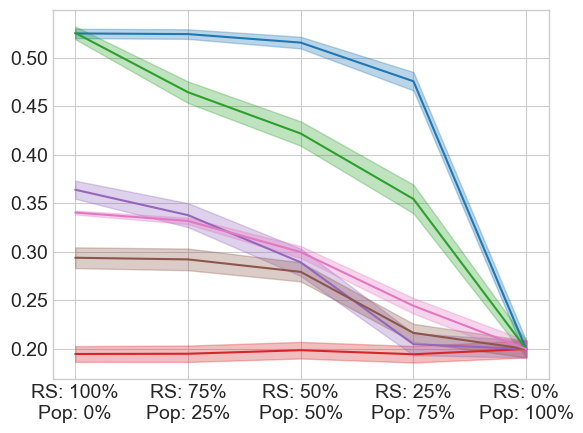

In [527]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(inter_user_div[mo].keys())]
    y_axis = np.array(list(inter_user_div[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### Intra-user Diversity

In [528]:
intra_user_div = dict()
for mo in interactions.keys():
    intra_user_div[mo] = dict()
    for fo in interactions[mo].keys():
        intra_user_div[mo][fo] = []
        for i in range(interactions[mo][fo].shape[0]):
            re = []
            user_iter_attrs = item_attrs[i].T[interactions[mo][fo][i]]
            for j in range(user_iter_attrs.shape[1]):
                mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
                distances = np.linalg.norm(diff_vectors, axis=2)
                variances = ((distances**2).sum(axis=1))/distances.shape[1]
                re.append((variances**0.5).mean())
            intra_user_div[mo][fo].append(re)
        intra_user_div[mo][fo] = np.array(intra_user_div[mo][fo])

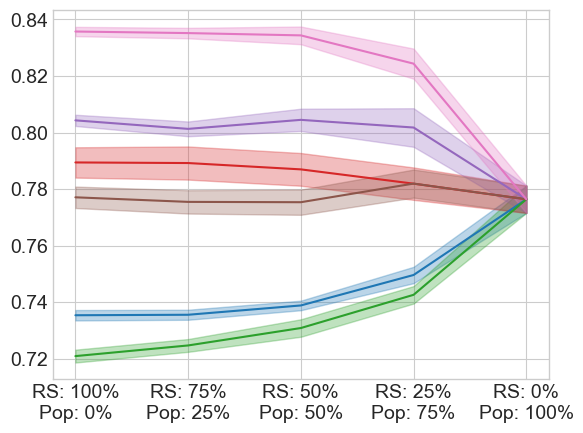

In [529]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(intra_user_div[mo].keys())]
    y_axis = np.array(list(intra_user_div[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### Filter Bubble Effect

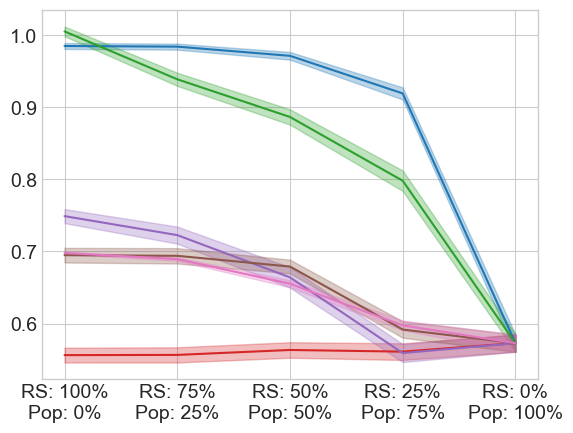

In [530]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(inter_user_div[mo].keys())]
    y_axis_1 = np.array(list(inter_user_div[mo].values()))[:,:,-1]
    y_axis_2 = np.array(list(intra_user_div[mo].values()))[:,:,-1]
    y_axis = (y_axis_1 / y_axis_2**2)**0.5
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### General Homogenization

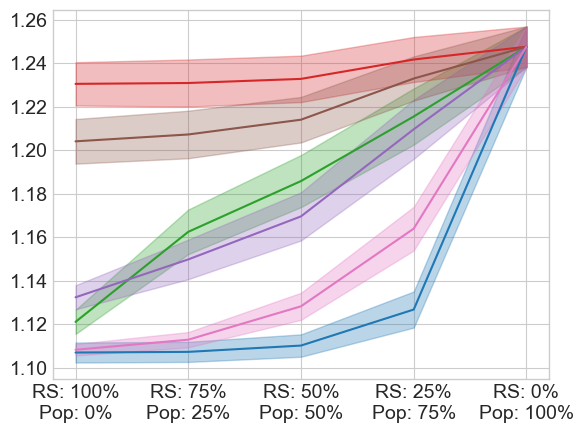

In [531]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(inter_user_div[mo].keys())]
    y_axis_1 = np.array(list(inter_user_div[mo].values()))[:,:,-1]
    y_axis_2 = np.array(list(intra_user_div[mo].values()))[:,:,-1]
    y_axis = 1 / (y_axis_1**2 + y_axis_2**2)**0.5
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### Similar Users Homogenization (Chamfer distance)

In [532]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [533]:
user_iter_attrs_ideal = np.array([item_attrs[i].T[interactions['ideal'][base_path + rs_100_no_rep_folder_path][i]] for i in range(interactions['ideal'][base_path + rs_100_no_rep_folder_path].shape[0])])

In [534]:
chamfer = dict()
for mo in interactions.keys():
    chamfer[mo] = dict()
    for fo in interactions[mo].keys():
        chamfer[mo][fo] = []
        for i in range(interactions[mo][fo].shape[0]):
            re = []
            user_iter_attrs = item_attrs[i].T[interactions[mo][fo][i]]
            for j in range(user_iter_attrs.shape[1]-2, user_iter_attrs.shape[1]): # sólo últimas 2 iters pq se tarda mucho
                mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                ideal_mean_user_attrs = user_iter_attrs_ideal[i,:,:(j+1)].mean(axis=2)
                nearest_users = get_sim_users_pairs(mean_user_attrs)
                chamfer_iter = 0
                ideal_chamfer_iter = 0
                for p in nearest_users:
                    d = compute_distance_matrix(user_iter_attrs[p[0],:(j+1)], user_iter_attrs[p[1],:(j+1)])
                    chamfer_iter += (d.min(axis=1).mean() + d.min(axis=0).mean()) / (2*len(nearest_users))

                    ideal_d = compute_distance_matrix(user_iter_attrs_ideal[i,p[0],:(j+1)], user_iter_attrs_ideal[i,p[1],:(j+1)])
                    ideal_chamfer_iter += (ideal_d.min(axis=1).mean() + ideal_d.min(axis=0).mean()) / (2*len(nearest_users))
                re.append(ideal_chamfer_iter - chamfer_iter)
            chamfer[mo][fo].append(re)
        chamfer[mo][fo] = np.array(chamfer[mo][fo])

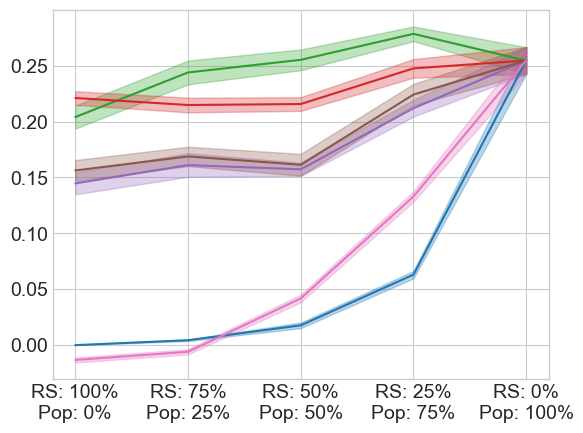

In [535]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(chamfer[mo].keys())]
    y_axis = np.array(list(chamfer[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

## Item distribution

### Gini

In [536]:
gini = dict()
for mo in interactions.keys():
    gini[mo] = dict()
    for fo in interactions[mo].keys():
        gini[mo][fo] = []
        for i in range(interactions[mo][fo].shape[0]):
            re = []
            for j in range(interactions[mo][fo][i].shape[1]-2, interactions[mo][fo][i].shape[1]):
                num_items = (j+1)*10
                user_iter_interactions = interactions[mo][fo][i,:,:(j+1)]
                numerator = 0.0
                denominator = 0.0
                gini_iter = 0
                for k in range(num_items):
                    user_interactions_for_item = (user_iter_interactions == k).any(axis=1).sum()
                    item_rank = np.argsort(np.argsort(np.bincount(user_iter_interactions.flatten(), minlength=num_items))[::-1])[k] + 1
                    numerator += ((2*item_rank) - num_items - 1) * user_interactions_for_item
                    denominator += user_interactions_for_item
                gini_iter = - numerator / (num_items * denominator)
                re.append(gini_iter)
            gini[mo][fo].append(re)
        gini[mo][fo] = np.array(gini[mo][fo])

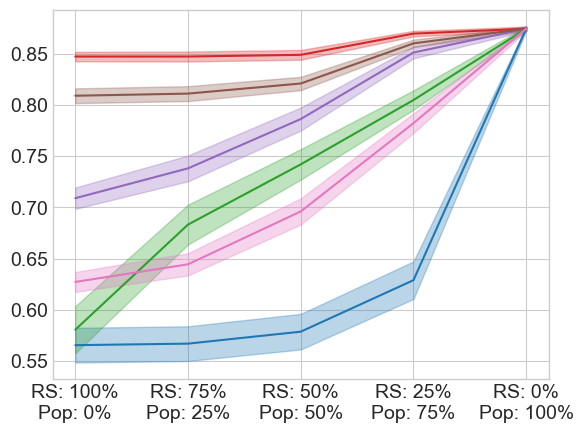

In [537]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(gini[mo].keys())]
    y_axis = np.array(list(gini[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### Coverage

In [538]:
cover = dict()
for mo in interactions.keys():
    cover[mo] = dict()
    for fo in interactions[mo].keys():
        cover[mo][fo] = []
        for i in range(interactions[mo][fo].shape[0]):
            re = []
            for j in range(interactions[mo][fo][i].shape[1]):
                num_items = (j+1)*10
                user_iter_interactions = interactions[mo][fo][i,:,:(j+1)]
                cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
                re.append(cover_iter)
            cover[mo][fo].append(re)
        cover[mo][fo] = np.array(cover[mo][fo])

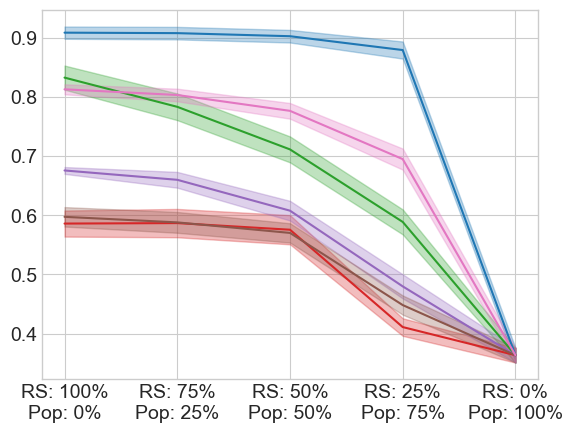

In [539]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(cover[mo].keys())]
    y_axis = np.array(list(cover[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

## Utilities

### Total Utility

In [540]:
tot_util = dict()
for mo in utilities.keys():
    tot_util[mo] = dict()
    for fo in utilities[mo].keys():
        tot_util[mo][fo] = []
        for i in range(utilities[mo][fo].shape[0]):
            re = []
            re.append(utilities[mo][fo][i].sum())
            tot_util[mo][fo].append(re)
        tot_util[mo][fo] = np.array(tot_util[mo][fo])

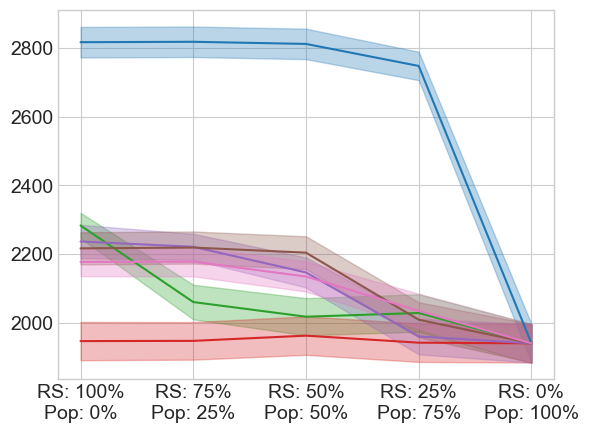

In [541]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(tot_util[mo].keys())]
    y_axis = np.array(list(tot_util[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

### Total User Utility

In [542]:
tot_user_util = dict()
for mo in utilities.keys():
    tot_user_util[mo] = dict()
    for fo in utilities[mo].keys():
        tot_user_util[mo][fo] = []
        for i in range(utilities[mo][fo].shape[0]):
            re = []
            re.append(utilities[mo][fo][i].mean())
            tot_user_util[mo][fo].append(re)
        tot_user_util[mo][fo] = np.array(tot_user_util[mo][fo])

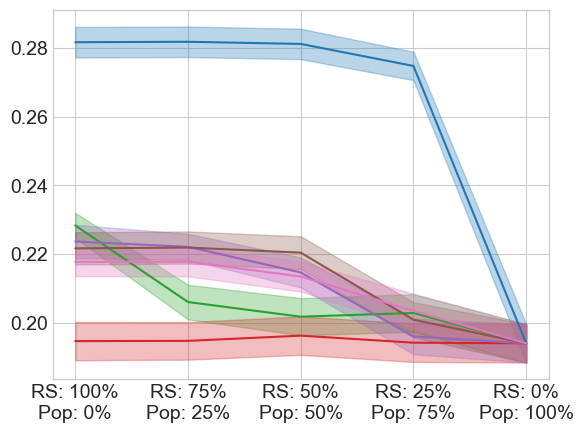

In [543]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(tot_user_util[mo].keys())]
    y_axis = np.array(list(tot_user_util[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()

## Choice Distribution

In [544]:
choices = dict()
for mo in utilities.keys():
    choices[mo] = dict()
    for fo in utilities[mo].keys():
        choices[mo][fo] = []
        for i in range(utilities[mo][fo].shape[0]):
            re = []
            re.append(decisions[mo][fo][i,0,-1]/(utilities[mo][fo].shape[1]*decisions[mo][fo].shape[2]))
            choices[mo][fo].append(re)
        choices[mo][fo] = np.array(choices[mo][fo])

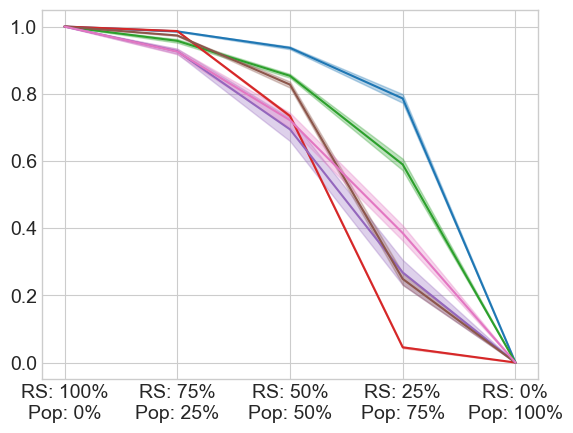

In [545]:
for mo in interactions.keys():
    x_axis_labels = results_to_readable #if mo != "content_reduced" else results_to_readable_CBF
    x_axis = [x_axis_labels[r] for r in list(choices[mo].keys())]
    y_axis = np.array(list(choices[mo].values()))[:,:,-1]
    values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
    plt.plot(x_axis, values, label=model_to_readable[mo], color=colors[mo])
    
    std = y_axis.std(axis=1)
    mtus = np.arange(len(std))
    low = values - mult_sd * std
    high = values + mult_sd * std
    low = gaussian_filter1d(low, sigma=plotting_sigma)
    high = gaussian_filter1d(high, sigma=plotting_sigma)
    plt.fill_between(mtus, low, high, color=colors[mo], alpha=0.3)
plt.show()